In [1]:
# %%
from pathlib import Path
import sys
sys.executable
import os
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.stats import pearsonr, spearmanr

REPO_ROOT = Path.cwd().parents[1]  # falls Notebook in notebooks/... liegt
DATA_PATH = REPO_ROOT / "data" / "all_heuristics_dataset.pkl"

OUT_DIR = REPO_ROOT / "data" / "outputs" / "ppp_global"
OUT_DIR.mkdir(parents=True, exist_ok=True)

PPP_TEMPLATE_PATH = REPO_ROOT / "src" / "prompt_templates" / "ppp_with_refs.md"

print("REPO_ROOT:", REPO_ROOT)
print("DATA_PATH exists:", DATA_PATH.exists(), DATA_PATH)
print("OUT_DIR:", OUT_DIR)
print("PPP_TEMPLATE_PATH exists:", PPP_TEMPLATE_PATH.exists(), PPP_TEMPLATE_PATH)

# make repo importable
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("sys.path[0]:", sys.path[0])


REPO_ROOT: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction
DATA_PATH exists: True c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\data\all_heuristics_dataset.pkl
OUT_DIR: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\data\outputs\ppp_global
PPP_TEMPLATE_PATH exists: True c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\src\prompt_templates\ppp_with_refs.md
sys.path[0]: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction


In [2]:
# %%
from pathlib import Path

CACHE_DIR = REPO_ROOT / "artifacts" / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

for p in [
    CACHE_DIR / "imi_cache.jsonl",
    CACHE_DIR / "deepseek_cache.jsonl",
]:
    if p.exists():
        p.unlink()
        print("Deleted cache:", p)
    else:
        print("No cache found:", p)


No cache found: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\artifacts\cache\imi_cache.jsonl
No cache found: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\artifacts\cache\deepseek_cache.jsonl


In [3]:
# %%
import os
from src.api.factory import get_llm_client

# Optional (falls du env-variablen setzen willst – nicht zwingend):
# os.environ["LLM_PROVIDER"] = "imi"
# os.environ["IMI_API_BASE_URL"] = "https://api3.imi-services.imi.kit.edu/api/generate"
# os.environ["IMI_MODEL"] = "qwen2.5-coder:14b"
# os.environ["IMI_API_KEY"] = ""  # im VPN meist leer

client = get_llm_client(provider="imi", enable_cache=False)

print("Client class:", type(client).__name__)
print("Cache disabled (client.cache is None):", getattr(client, "cache", None) is None)

# Preflight
resp = client.generate('Return JSON only: {"ping":"pong"}', temperature=0.0, max_tokens=30)
print(resp.text[:120])


Client class: IMILLMClient
Cache disabled (client.cache is None): True
```json
{"ping":"pong"}
```


In [4]:
# %%
df = pd.read_pickle(DATA_PATH)

required = {"heuristic_id", "raw_app_type", "code", "objective"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df.dropna(subset=["code", "objective"]).copy()
df["heuristic_id"] = df["heuristic_id"].astype(str)
df["raw_app_type"] = df["raw_app_type"].astype(str)
df["objective"] = pd.to_numeric(df["objective"], errors="coerce")
df = df.dropna(subset=["objective"]).reset_index(drop=True)

print("Usable rows:", len(df))
df.head(3)


Usable rows: 15507


,heuristic_id,raw_app_type,instance_scale,filename,strategy,algorithm,code,objective,task_name,parse_ok,is_timeout
0,pop_0_op_e1_n0_251224_134701,bin_greedy,results_20251224_134317_bp_online_qwen25coder3...,program_pop_0_op_e1_n0_251224_134701.json,e1,The new algorithm assigns scores based on a co...,"import numpy as np\n\ndef score(item, bins):\n...",1.51534,BinPacking,True,False
1,pop_0_op_e1_n10_251224_134701,bin_greedy,results_20251224_134317_bp_online_qwen25coder3...,program_pop_0_op_e1_n10_251224_134701.json,e1,The new algorithm calculates scores for each b...,"import numpy as np\n\ndef score(item, bins):\n...",0.32770,BinPacking,True,False
2,pop_0_op_e1_n11_251224_134701,bin_greedy,results_20251224_134317_bp_online_qwen25coder3...,program_pop_0_op_e1_n11_251224_134701.json,e1,The new algorithm calculates scores for each b...,"import numpy as np\n\ndef score(item, bins):\n...",1.51534,BinPacking,True,False


In [5]:
# %%
task_bounds = (
    df.groupby("raw_app_type")["objective"]
      .agg(["min", "max"])
      .to_dict(orient="index")
)
task_bounds


{'bin_greedy': {'min': 0.00563, 'max': 1.51534},
 'cvrp_lns': {'min': 3343425.3, 'max': 3981765.6},
 'premarshalling_astar': {'min': 0.08148, 'max': 13.9329},
 'puzzle_astar': {'min': 0.4574, 'max': 3.65888}}

In [6]:
# %%
N_PER_TASK = 200

df = (
    df.sort_values(["raw_app_type"])  # stabile Gruppierung
      .groupby("raw_app_type", group_keys=False)
      .head(N_PER_TASK)
      .reset_index(drop=True)
)

print("Rows after limiting:", len(df))
print(df["raw_app_type"].value_counts())


Rows after limiting: 800
raw_app_type
bin_greedy              200
cvrp_lns                200
premarshalling_astar    200
puzzle_astar            200
Name: count, dtype: int64


In [7]:
# %%
import numpy as np

def select_refs_stratified(df_task: pd.DataFrame, target_id: str, k: int = 7):
    df_cand = (
        df_task[df_task["heuristic_id"] != target_id]
        .sort_values("objective", ascending=True)
        .reset_index(drop=True)
    )
    n = len(df_cand)
    if n < k:
        return None

    # evenly spaced quantiles incl. ends
    idxs = np.linspace(0, n - 1, k).round().astype(int).tolist()

    refs = []
    seen = set()
    for i in idxs:
        row = df_cand.iloc[int(i)]
        hid = str(row["heuristic_id"])
        if hid not in seen:
            refs.append(row)
            seen.add(hid)

    # safety: fill if duplicates collapsed
    if len(refs) < k:
        for _, row in df_cand.iterrows():
            hid = str(row["heuristic_id"])
            if hid not in seen:
                refs.append(row)
                seen.add(hid)
            if len(refs) >= k:
                break

    return refs[:k]


def build_refs_block(refs):
    lines = []
    for i, r in enumerate(refs, 1):
        lines += [
            f"{i})",
            "Heuristic code:",
            "```python",
            str(r["code"]),
            "```",
            f"Objective: {float(r['objective'])}",
            ""
        ]
    return "\n".join(lines).strip() + "\n"


In [8]:
# %%
ppp_template = PPP_TEMPLATE_PATH.read_text(encoding="utf-8")

def render_ppp_prompt(*, raw_app_type, task_min, task_max, references_block, target_code):
    return ppp_template.format(
        raw_app_type=raw_app_type,
        task_min=task_min,
        task_max=task_max,
        references_block=references_block,
        target_code=target_code,
    )

print("Template loaded, length:", len(ppp_template))


Template loaded, length: 752


In [9]:
# %%
from src.api.parse import parse_ppp_response


In [10]:
# %%
TEST_PER_TASK = 3

for app, df_task in df.groupby("raw_app_type"):
    task_min = task_bounds[app]["min"]
    task_max = task_bounds[app]["max"]

    print("\n=== APP:", app, "| rows:", len(df_task), "| range:", (task_min, task_max))
    df_small = df_task.head(TEST_PER_TASK)

    for _, row in df_small.iterrows():
        hid = row["heuristic_id"]
        refs = select_refs_stratified(df_task, hid, k=5)
        if refs is None:
            print("No refs for", hid)
            continue

        prompt = render_ppp_prompt(
            raw_app_type=app,
            task_min=task_min,
            task_max=task_max,
            references_block=build_refs_block(refs),
            target_code=str(row["code"]),
        )

        resp = client.generate(prompt, temperature=0.2, max_tokens=512)
        pred, conf, ok, err, _ = parse_ppp_response(resp.text)

        if pred is not None:
            pred = max(task_min, min(task_max, pred))  # clamp to bounds

        print("hid:", hid, "| obj:", row["objective"], "| pred:", pred, "| conf:", conf, "| ok:", ok, "| err:", err)



=== APP: bin_greedy | rows: 200 | range: (0.00563, 1.51534)
hid: pop_0_op_e1_n0_251224_134701 | obj: 1.51534 | pred: 0.02 | conf: 0.75 | ok: True | err: None
hid: pop_9_op_m1_n1_251224_221631 | obj: 0.00986 | pred: 0.414935 | conf: 0.95 | ok: True | err: None
hid: pop_9_op_m1_n2_251224_221631 | obj: 0.02837 | pred: 0.25202 | conf: 0.85 | ok: True | err: None

=== APP: cvrp_lns | rows: 200 | range: (3343425.3, 3981765.6)
hid: pop_3_op_e1_n4_251226_003906 | obj: 3760716.5 | pred: 3500000.0 | conf: 0.85 | ok: True | err: None
hid: pop_3_op_e1_n1_251226_003906 | obj: 3973677.1 | pred: 3700000.0 | conf: 0.8 | ok: True | err: None
hid: pop_3_op_e1_n6_251226_003906 | obj: 3875729.5 | pred: 3700000.0 | conf: 0.9 | ok: True | err: None

=== APP: premarshalling_astar | rows: 200 | range: (0.08148, 13.9329)
hid: pop_9_op_m2_n1_250821_192903 | obj: 8.79957 | pred: 0.5 | conf: 0.6 | ok: True | err: None
hid: pop_9_op_m2_n3_250821_192903 | obj: 10.69957 | pred: 2.5 | conf: 0.75 | ok: True | err: No

In [11]:
# %%
RUN_TAG = "imi_k5_n200"  # statt deepseek_k5
PPP_PKL = OUT_DIR / f"ppp_results_{RUN_TAG}.pkl"
PPP_CSV = OUT_DIR / f"ppp_results_{RUN_TAG}.csv"

if PPP_PKL.exists():
    prev = pd.read_pickle(PPP_PKL)
    prev["heuristic_id"] = prev["heuristic_id"].astype(str)
    done_ids = set(prev["heuristic_id"])  # wir resumieren auf Basis: "row existiert"
    results = prev.to_dict(orient="records")
    print("Resuming, loaded:", len(done_ids))
else:
    done_ids = set()
    results = []

t0 = time.time()

for app, df_task in df.groupby("raw_app_type"):
    task_min = task_bounds[app]["min"]
    task_max = task_bounds[app]["max"]

    for _, row in tqdm(df_task.iterrows(), total=len(df_task), desc=f"PPP [{app}]"):
        hid = str(row["heuristic_id"])
        if hid in done_ids:
            continue

        refs = select_refs_stratified(df_task, hid, k=5)
        if refs is None:
            results.append({
                "heuristic_id": hid,
                "raw_app_type": app,
                "objective": float(row["objective"]),
                "prediction": None,
                "confidence": None,
                "parse_ok": False,
                "parse_error": "Not enough reference heuristics for k=5",
            })
            done_ids.add(hid)
            continue

        prompt = render_ppp_prompt(
            raw_app_type=app,
            task_min=task_min,
            task_max=task_max,
            references_block=build_refs_block(refs),
            target_code=str(row["code"]),
        )

        try:
            resp = client.generate(
                prompt,
                temperature=0.2,
                max_tokens=512,
                meta={"stage": "ppp", "heuristic_id": hid, "raw_app_type": app},
            )

            pred, conf, ok, err, _ = parse_ppp_response(resp.text)

            if pred is not None:
                pred = max(task_min, min(task_max, pred))  # clamp

            results.append({
                "heuristic_id": hid,
                "raw_app_type": app,
                "objective": float(row["objective"]),
                "prediction": pred,
                "confidence": conf,
                "parse_ok": bool(ok),
                "parse_error": err,
            })

        except Exception as e:
            results.append({
                "heuristic_id": hid,
                "raw_app_type": app,
                "objective": float(row["objective"]),
                "prediction": None,
                "confidence": None,
                "parse_ok": False,
                "parse_error": f"LLM call failed: {type(e).__name__}: {e}",
            })

        done_ids.add(hid)

        if len(results) % 200 == 0:
            tmp = pd.DataFrame(results)
            tmp.to_pickle(PPP_PKL)
            tmp.to_csv(PPP_CSV, index=False)
            print("[checkpoint] saved", len(results))

elapsed = time.time() - t0
ppp_df = pd.DataFrame(results)
ppp_df.to_pickle(PPP_PKL)
ppp_df.to_csv(PPP_CSV, index=False)

print("DONE. Rows:", len(ppp_df), "Time(s):", round(elapsed, 1))
print("Saved:", PPP_PKL)
print("Saved:", PPP_CSV)
ppp_df.head()


PPP [bin_greedy]: 100%|██████████| 200/200 [07:43<00:00,  2.32s/it]


[checkpoint] saved 200


PPP [cvrp_lns]:  60%|██████    | 121/200 [07:30<09:22,  7.12s/it]

[IMILLMClient] retry 1/5 in 1.24s due to LLMTemporaryError


PPP [cvrp_lns]: 100%|██████████| 200/200 [14:13<00:00,  4.27s/it]


...

PPP [puzzle_astar]:  16%|█▋        | 33/200 [01:39<14:39,  5.27s/it]

[IMILLMClient] retry 1/5 in 1.27s due to LLMTemporaryError


PPP [puzzle_astar]: 100%|██████████| 200/200 [08:22<00:00,  2.51s/it]

[checkpoint] saved 800
DONE. Rows: 800 Time(s): 2412.9
Saved: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\data\outputs\ppp_global\ppp_results_imi_k5_n200.pkl
Saved: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\data\outputs\ppp_global\ppp_results_imi_k5_n200.csv


,heuristic_id,raw_app_type,objective,prediction,confidence,parse_ok,parse_error
0,pop_0_op_e1_n0_251224_134701,bin_greedy,1.51534,0.020000,0.80,True,None
1,pop_9_op_m1_n1_251224_221631,bin_greedy,0.00986,0.020000,0.85,True,None
2,pop_9_op_m1_n2_251224_221631,bin_greedy,0.02837,0.025000,0.80,True,None
3,pop_9_op_m1_n3_251224_221631,bin_greedy,0.04256,0.414935,0.65,True,None
4,pop_9_op_m1_n4_251224_221631,bin_greedy,0.03441,0.289750,0.70,True,None


In [16]:
# %%
import pandas as pd

PPP_CSV = OUT_DIR / f"ppp_results_{RUN_TAG}.csv"
prev = pd.read_csv(PPP_CSV)
prev["heuristic_id"] = prev["heuristic_id"].astype(str)

done_ids = set(prev["heuristic_id"])
results = prev.to_dict(orient="records")

print("Resuming from CSV. Done:", len(done_ids))


Resuming from CSV. Done: 800


In [17]:
# %%
from scipy.stats import pearsonr, spearmanr

def topk_overlap(pred, true, ids, k=10):
    assert len(pred) == len(true) == len(ids)

    idx_pred = sorted(range(len(pred)), key=lambda i: pred[i])
    idx_true = sorted(range(len(true)), key=lambda i: true[i])

    top_pred = set(ids[i] for i in idx_pred[:k])
    top_true = set(ids[i] for i in idx_true[:k])

    return len(top_pred & top_true) / k


In [18]:
# %%
import pandas as pd
import numpy as np

K_TOP = 10

results_eval = []

for app, df_task in ppp_df.groupby("raw_app_type"):
    df_task = df_task.dropna(subset=["prediction", "objective"])
    if len(df_task) < K_TOP:
        continue

    pred = df_task["prediction"].values
    true = df_task["objective"].values
    ids  = df_task["heuristic_id"].astype(str).values

    pearson_r, _  = pearsonr(pred, true)
    spearman_r, _ = spearmanr(pred, true)
    overlap_k     = topk_overlap(pred, true, ids, k=K_TOP)

    results_eval.append({
        "task": app,
        "n": len(df_task),
        "pearson": pearson_r,
        "spearman": spearman_r,
        f"top_{K_TOP}_overlap": overlap_k,
    })

eval_df = pd.DataFrame(results_eval)
eval_df


,task,n,pearson,spearman,top_10_overlap
0,bin_greedy,200,-0.032643,-0.009989,0.1
1,cvrp_lns,200,-0.040109,-0.054326,0.0
2,premarshalling_astar,200,-0.026887,-0.155904,0.1
3,puzzle_astar,200,-0.007536,-0.059977,0.0


In [20]:
# %%
import time
import numpy as np
import pandas as pd

# --- Setup ---
RUN_TAG_REP = "imi_one_per_task_repeats"
PPP_REP_PKL = OUT_DIR / f"ppp_repeats_{RUN_TAG_REP}.pkl"
PPP_REP_CSV = OUT_DIR / f"ppp_repeats_{RUN_TAG_REP}.csv"

N_REPEATS = 10
K_REFS    = 5
TEMP      = 0.2
MAX_TOKENS= 512

# Welche Heuristik pro Task?
# "first"  -> erste Heuristik in CSV-Reihenfolge pro raw_app_type
# 20       -> die 21. Heuristik (wie in deinem Plot-Beispiel mit iloc[20])
PICK_MODE = "first"   # oder: PICK_MODE = 20

TASK_ORDER = ["cvrp_lns", "premarshalling_astar", "puzzle_astar", "bin_greedy"]

print("Will run:", {"PICK_MODE": PICK_MODE, "N_REPEATS": N_REPEATS, "K_REFS": K_REFS})
print("Output:", PPP_REP_CSV)

# --- pick 1 heuristic per task (wie dein Plot-Block) ---
df_ids = df.copy()
df_ids["heuristic_id"] = df_ids["heuristic_id"].astype(str)
df_ids["raw_app_type"] = df_ids["raw_app_type"].astype(str)

def pick_hid(s: pd.Series):
    if PICK_MODE == "first":
        return s.iloc[0]
    else:
        idx = int(PICK_MODE)
        if len(s) <= idx:
            return s.iloc[0]   # fallback
        return s.iloc[idx]

one_hid = (
    df_ids.groupby("raw_app_type")["heuristic_id"]
          .apply(pick_hid)
          .to_dict()
)

tasks_available = list(df_ids["raw_app_type"].unique())
tasks = [t for t in TASK_ORDER if t in tasks_available]
if len(tasks) == 0:
    raise RuntimeError("Keine passenden Tasks gefunden.")

print("Chosen heuristic per task:")
for t in tasks:
    print(t, "->", one_hid[t])

# --- resume ---
if PPP_REP_PKL.exists():
    prev = pd.read_pickle(PPP_REP_PKL)
    prev["heuristic_id"] = prev["heuristic_id"].astype(str)
    done = set(zip(prev["heuristic_id"], prev["repeat_idx"]))
    results = prev.to_dict(orient="records")
    print("Resuming:", len(done), "done")
else:
    done = set()
    results = []

t0 = time.time()

# --- run repeats only for 1 heuristic per task ---
for task in tasks:
    hid = one_hid[task]

    df_task = df_ids[df_ids["raw_app_type"] == task].reset_index(drop=True)
    row = df_task[df_task["heuristic_id"] == hid].iloc[0]

    task_min = task_bounds[task]["min"]
    task_max = task_bounds[task]["max"]

    refs = select_refs_stratified(df_task, hid, k=K_REFS)
    if refs is None:
        raise RuntimeError(f"Not enough refs for task={task} hid={hid} with k={K_REFS}")

    prompt = render_ppp_prompt(
        raw_app_type=task,
        task_min=task_min,
        task_max=task_max,
        references_block=build_refs_block(refs),
        target_code=str(row["code"]),
    )

    for r in range(N_REPEATS):
        key = (hid, r)
        if key in done:
            continue

        try:
            resp = client.generate(
                prompt,
                temperature=TEMP,
                max_tokens=MAX_TOKENS,
                meta={"stage": "ppp_repeat_one", "heuristic_id": hid, "raw_app_type": task, "repeat_idx": r},
            )

            pred, conf, ok, err, _ = parse_ppp_response(resp.text)

            pred_raw = pred
            pred_clamped = None
            if pred is not None:
                pred_clamped = max(task_min, min(task_max, pred))

            results.append({
                "heuristic_id": hid,
                "raw_app_type": task,
                "objective": float(row["objective"]),
                "repeat_idx": r,
                "prediction_raw": pred_raw,
                "prediction_clamped": pred_clamped,
                "confidence": conf,
                "parse_ok": bool(ok),
                "parse_error": err,
            })

        except Exception as e:
            results.append({
                "heuristic_id": hid,
                "raw_app_type": task,
                "objective": float(row["objective"]),
                "repeat_idx": r,
                "prediction_raw": None,
                "prediction_clamped": None,
                "confidence": None,
                "parse_ok": False,
                "parse_error": f"LLM call failed: {type(e).__name__}: {e}",
            })

        done.add(key)

# save
rep_df = pd.DataFrame(results)
rep_df.to_pickle(PPP_REP_PKL)
rep_df.to_csv(PPP_REP_CSV, index=False)

print("DONE. Rows:", len(rep_df), "Time(s):", round(time.time() - t0, 1))
print("Saved:", PPP_REP_PKL)
print("Saved:", PPP_REP_CSV)

rep_df.sort_values(["raw_app_type","repeat_idx"]).head(20)


Will run: {'PICK_MODE': 'first', 'N_REPEATS': 10, 'K_REFS': 5}
Output: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\data\outputs\ppp_global\ppp_repeats_imi_one_per_task_repeats.csv
Chosen heuristic per task:
cvrp_lns -> pop_3_op_e1_n4_251226_003906
premarshalling_astar -> pop_9_op_m2_n1_250821_192903
puzzle_astar -> pop_9_op_m2_n1_251008_132009
bin_greedy -> pop_0_op_e1_n0_251224_134701
DONE. Rows: 40 Time(s): 137.7
Saved: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\data\outputs\ppp_global\ppp_repeats_imi_one_per_task_repeats.pkl
Saved: c:\Users\abder\OneDrive\Desktop\Desktop\ppp-performance-prediction\data\outputs\ppp_global\ppp_repeats_imi_one_per_task_repeats.csv


,heuristic_id,raw_app_type,objective,repeat_idx,prediction_raw,prediction_clamped,confidence,parse_ok,parse_error
30,pop_0_op_e1_n0_251224_134701,bin_greedy,1.515340e+00,0,2.000000e-02,2.000000e-02,0.85,True,None
31,pop_0_op_e1_n0_251224_134701,bin_greedy,1.515340e+00,1,2.700000e-02,2.700000e-02,0.70,True,None
32,pop_0_op_e1_n0_251224_134701,bin_greedy,1.515340e+00,2,2.189000e-02,2.189000e-02,0.85,True,None
33,pop_0_op_e1_n0_251224_134701,bin_greedy,1.515340e+00,3,2.000000e-02,2.000000e-02,0.85,True,None
34,pop_0_op_e1_n0_251224_134701,bin_greedy,1.515340e+00,4,2.000000e-02,2.000000e-02,0.75,True,None
35,pop_0_op_e1_n0_251224_134701,bin_greedy,1.515340e+00,5,2.000000e-02,2.000000e-02,0.75,True,None
36,pop_0_op_e1_n0_251224_134701,bin_greedy,1.515340e+00,6,9.718500e-01,9.718500e-01,0.75,True,None
37,pop_0_op_e1_n0_251224_134701,bin_greedy,1.515340e+00,7,2.000000e-02,2.000000e-02,0.80,True,None
38,pop_0_op_e1_n0_251224_134701,bin_greedy,1.515340e+00,8,2.900000e-02,2.900000e-02,0.80,True,None
39,pop_0_op_e1_n0_251224_134701,bin_greedy,1.515340e+00,9,2.000000e-02,2.000000e-02,0.85,True,None


In [21]:
# %%
import pandas as pd

rep = pd.read_csv(PPP_REP_CSV)  # oder OUT_CSV, je nachdem wie du es genannt hast
rep["heuristic_id"] = rep["heuristic_id"].astype(str)
rep["raw_app_type"] = rep["raw_app_type"].astype(str)

print("Rows:", len(rep))
print("Tasks:", rep["raw_app_type"].nunique())
print("Unique heuristic_ids:", rep["heuristic_id"].nunique())

print("\nRepeats per (task, heuristic):")
print(rep.groupby(["raw_app_type","heuristic_id"])["repeat_idx"].nunique())

print("\nHeuristics per task:")
print(rep.groupby("raw_app_type")["heuristic_id"].nunique())


Rows: 40
Tasks: 4
Unique heuristic_ids: 4

Repeats per (task, heuristic):
raw_app_type          heuristic_id                
bin_greedy            pop_0_op_e1_n0_251224_134701    10
cvrp_lns              pop_3_op_e1_n4_251226_003906    10
premarshalling_astar  pop_9_op_m2_n1_250821_192903    10
puzzle_astar          pop_9_op_m2_n1_251008_132009    10
Name: repeat_idx, dtype: int64

Heuristics per task:
raw_app_type
bin_greedy              1
cvrp_lns                1
premarshalling_astar    1
puzzle_astar            1
Name: heuristic_id, dtype: int64


In [22]:
# %%
import numpy as np
import pandas as pd
import time

from src.api.factory import get_llm_client
from src.api.parse import parse_ppp_response

# IMI / KIT Client ohne Cache
client = get_llm_client(provider="imi", enable_cache=False)

print("Client class:", type(client).__name__)
print("Cache disabled (client.cache is None):", getattr(client, "cache", None) is None)

# Preflight
resp = client.generate('Return JSON only: {"ping":"pong"}', temperature=0.0, max_tokens=30)
print("Preflight:", resp.text[:120])


Client class: IMILLMClient
Cache disabled (client.cache is None): True
Preflight: ```json
{"ping":"pong"}
```


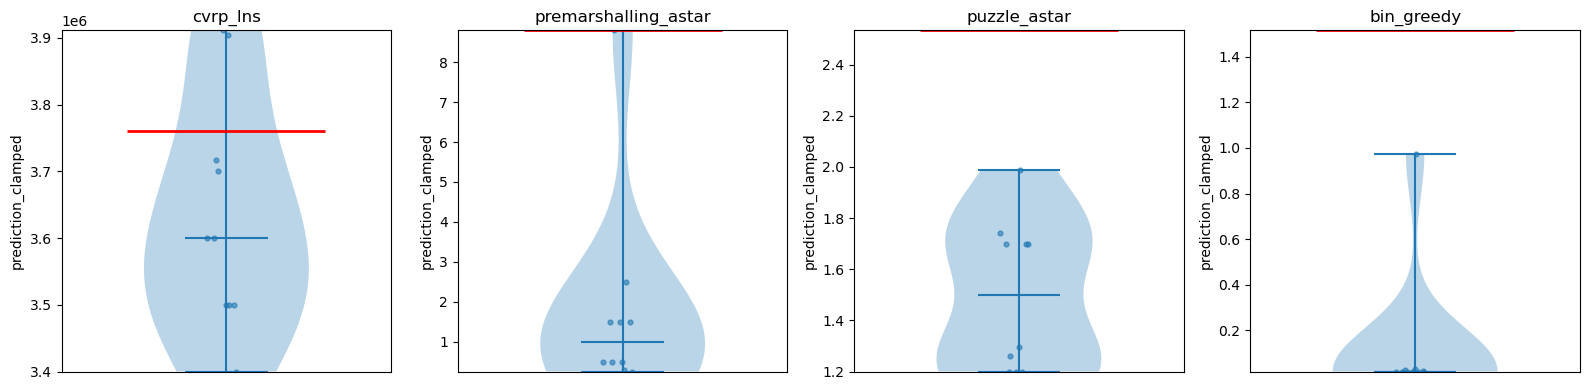

Plotted first heuristic per task:
cvrp_lns: pop_3_op_e1_n4_251226_003906
premarshalling_astar: pop_9_op_m2_n1_250821_192903
puzzle_astar: pop_9_op_m2_n1_251008_132009
bin_greedy: pop_0_op_e1_n0_251224_134701


In [24]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- CONFIG ----------------
# Nimm die REPEAT-CSV (die mit repeat_idx + prediction_clamped)
# Falls du sie anders genannt hast (z.B. OUT_CSV), setz CSV_PATH entsprechend.
CSV_PATH = PPP_REP_CSV   # <-- ggf. anpassen (z.B. CSV_PATH = OUT_CSV)

FIG_W = 16               # Gesamtbreite
FIG_H = 4                # Gesamthöhe

Y_SCALE = "linear"       # "linear" oder "log"
SHOW_POINTS = True       # einzelne Repeat-Punkte anzeigen

TASK_ORDER = ["cvrp_lns", "premarshalling_astar", "puzzle_astar", "bin_greedy"]
PRED_COL = "prediction_clamped"  # oder "prediction_raw"

# ---------------- LOAD ----------------
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=[PRED_COL]).copy()
df["heuristic_id"] = df["heuristic_id"].astype(str)
df["raw_app_type"] = df["raw_app_type"].astype(str)

# Erste Heuristik pro Task (in CSV-Reihenfolge)
first_hid = (
    df.groupby("raw_app_type")["heuristic_id"]
      .apply(lambda s: s.iloc[0])
      .to_dict()
)

tasks_available = list(df["raw_app_type"].unique())
tasks = [t for t in TASK_ORDER if t in tasks_available]

if len(tasks) == 0:
    raise RuntimeError("Keine passenden Tasks gefunden.")

# ---------------- PLOT ----------------
fig, axes = plt.subplots(1, len(tasks), figsize=(FIG_W, FIG_H))

if len(tasks) == 1:
    axes = [axes]  # fallback falls nur 1 task

for ax, task in zip(axes, tasks):
    hid = first_hid[task]
    d = df[(df["raw_app_type"] == task) & (df["heuristic_id"] == hid)]

    preds = d[PRED_COL].values
    objective = float(d["objective"].iloc[0])

    # Violin
    ax.violinplot(preds, showmeans=False, showmedians=True)

    # Objective als rote Linie
    ax.hlines(objective, 0.7, 1.3, colors="red", linewidth=2)

    # Optional: einzelne Punkte
    if SHOW_POINTS:
        rng = np.random.default_rng(42)
        jitter = rng.normal(0, 0.03, size=len(preds))
        ax.scatter(np.full(len(preds), 1) + jitter, preds, s=12, alpha=0.6)

    # Layout
    ax.set_title(task)
    ax.set_xticks([])
    ax.set_ylabel(PRED_COL)
    ax.set_yscale(Y_SCALE)
    ax.autoscale(enable=True, axis="y", tight=True)
    ax.set_xlim(0.5, 1.5)  # optional: hält Violin mittig/sauber

plt.tight_layout()
plt.show()

print("Plotted first heuristic per task:")
for t in tasks:
    print(f"{t}: {first_hid[t]}")


Rows total: 40

Distinct heuristics per task:
raw_app_type
bin_greedy              1
cvrp_lns                1
premarshalling_astar    1
puzzle_astar            1
Name: heuristic_id, dtype: int64

Rows per task (incl repeats):
raw_app_type
bin_greedy              10
cvrp_lns                10
premarshalling_astar    10
puzzle_astar            10
dtype: int64

Picked heuristic per task:
cvrp_lns: pop_3_op_e1_n4_251226_003906
premarshalling_astar: pop_9_op_m2_n1_250821_192903
puzzle_astar: pop_9_op_m2_n1_251008_132009
bin_greedy: pop_0_op_e1_n0_251224_134701


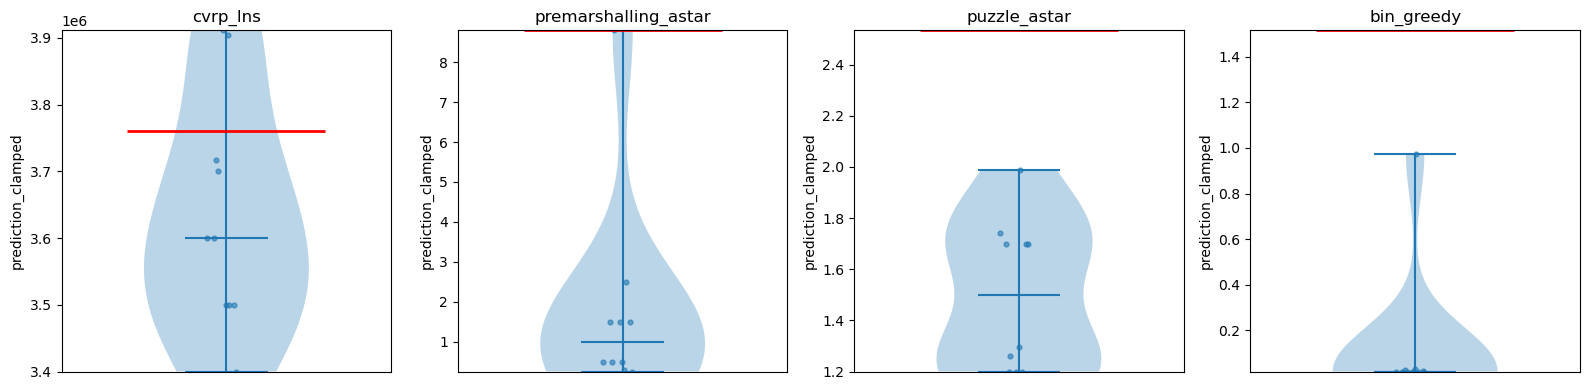


Plotted DISTINCT heuristic iloc[20] per task (ON_OOB=fallback_last):
cvrp_lns: pop_3_op_e1_n4_251226_003906
premarshalling_astar: pop_9_op_m2_n1_250821_192903
puzzle_astar: pop_9_op_m2_n1_251008_132009
bin_greedy: pop_0_op_e1_n0_251224_134701


In [30]:
# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
CSV_PATH = PPP_REP_CSV          # <- Repeat-CSV (mit repeat_idx + prediction_clamped)
FIG_W = 16
FIG_H = 4
Y_SCALE = "linear"             # "linear" oder "log"
SHOW_POINTS = True

TASK_ORDER = ["cvrp_lns", "premarshalling_astar", "puzzle_astar", "bin_greedy"]
PRED_COL = "prediction_clamped"  # oder "prediction_raw"

# Heuristik-Index wie bei deinem Kollegen: 0 / 20 / 30 ...
# WICHTIG: Das bezieht sich bei uns sauber auf DISTINCT heuristics pro Task.
IDX = 20

# Wenn es weniger distinct heuristics gibt als IDX+1:
# - "error": exakt wie Kollege -> knallt
# - "fallback_last": nimmt die letzte verfügbare distinct heuristic
# - "fallback_first": nimmt die erste distinct heuristic
ON_OOB = "fallback_last"  # "error" | "fallback_last" | "fallback_first"

# ============================================================
# LOAD
# ============================================================
df = pd.read_csv(CSV_PATH)
df = df.dropna(subset=[PRED_COL]).copy()
df["heuristic_id"] = df["heuristic_id"].astype(str)
df["raw_app_type"] = df["raw_app_type"].astype(str)

# ============================================================
# SANITY CHECKS (damit du sofort siehst warum iloc[20] crasht)
# ============================================================
print("Rows total:", len(df))
print("\nDistinct heuristics per task:")
print(df.groupby("raw_app_type")["heuristic_id"].nunique())
print("\nRows per task (incl repeats):")
print(df.groupby("raw_app_type").size())

# ============================================================
# PICK: heuristic iloc[IDX] pro Task – aber auf DISTINCT heuristic_id
# ============================================================
def pick_distinct_hid(s: pd.Series) -> str:
    u = s.drop_duplicates().reset_index(drop=True)
    if IDX < len(u):
        return u.iloc[IDX]

    if ON_OOB == "error":
        raise IndexError(f"Task has only {len(u)} distinct heuristics, cannot take iloc[{IDX}]")

    if ON_OOB == "fallback_first":
        return u.iloc[0]

    # default: fallback_last
    return u.iloc[-1]

picked_hid = (
    df.groupby("raw_app_type")["heuristic_id"]
      .apply(pick_distinct_hid)
      .to_dict()
)

tasks_available = list(df["raw_app_type"].unique())
tasks = [t for t in TASK_ORDER if t in tasks_available]
if len(tasks) == 0:
    raise RuntimeError("Keine passenden Tasks gefunden.")

print("\nPicked heuristic per task:")
for t in tasks:
    print(f"{t}: {picked_hid[t]}")

# ============================================================
# PLOT
# ============================================================
fig, axes = plt.subplots(1, len(tasks), figsize=(FIG_W, FIG_H))
if len(tasks) == 1:
    axes = [axes]

for ax, task in zip(axes, tasks):
    hid = picked_hid[task]
    d = df[(df["raw_app_type"] == task) & (df["heuristic_id"] == hid)]

    preds = d[PRED_COL].values
    objective = float(d["objective"].iloc[0])

    ax.violinplot(preds, showmeans=False, showmedians=True)
    ax.hlines(objective, 0.7, 1.3, colors="red", linewidth=2)

    if SHOW_POINTS:
        rng = np.random.default_rng(42)
        jitter = rng.normal(0, 0.03, size=len(preds))
        ax.scatter(np.full(len(preds), 1) + jitter, preds, s=12, alpha=0.6)

    ax.set_title(task)
    ax.set_xticks([])
    ax.set_ylabel(PRED_COL)
    ax.set_yscale(Y_SCALE)
    ax.autoscale(enable=True, axis="y", tight=True)
    ax.set_xlim(0.5, 1.5)

plt.tight_layout()
plt.show()

print(f"\nPlotted DISTINCT heuristic iloc[{IDX}] per task (ON_OOB={ON_OOB}):")
for t in tasks:
    print(f"{t}: {picked_hid[t]}")


In [31]:
# %%
from src.api.factory import get_llm_client

client = get_llm_client(provider="imi", enable_cache=False)

print("Client class:", type(client).__name__)

# IMI/KIT-Client hat typischerweise diese Attribute:
print("Endpoint:", getattr(client, "endpoint", None))
print("Base URL (cfg):", getattr(getattr(client, "cfg", None), "base_url", None))
print("Model (cfg):", getattr(getattr(client, "cfg", None), "model", None))

print("Cache disabled:", getattr(client, "cache", None) is None)


Client class: IMILLMClient
Endpoint: https://api3.imi-services.imi.kit.edu/api/generate
Base URL (cfg): https://api3.imi-services.imi.kit.edu/api/generate
Model (cfg): qwen2.5-coder:14b
Cache disabled: True
